# Exploratory Data Analysis - Stock Price Data

This notebook explores 2 years of historical price data for 5 tickers (AAPL, MSFT, GOOGL, AMZN, SPY), checking data quality and identyfying trends before building the forecasting model.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/stock_data.csv", parse_dates=["Date"])
df.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2024-09-10 00:00:00-04:00,AAPL,217.103866,219.642626,214.932032,218.283997,51591000
1,2024-09-11 00:00:00-04:00,AAPL,219.622839,221.239307,216.082448,220.812881,44587100
2,2024-09-12 00:00:00-04:00,AAPL,220.654187,221.695479,217.996427,220.921951,37455600
3,2024-09-13 00:00:00-04:00,AAPL,221.725217,222.181393,220.069073,220.654175,36766600
4,2024-09-16 00:00:00-04:00,AAPL,214.743628,215.417995,212.145368,214.525467,59357400


In [3]:
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Shape: (2506, 7)

Column types:
Date          str
Ticker        str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Missing values:
Date      0
Ticker    0
Open      1
High      1
Low       1
Close     1
Volume    0
dtype: int64

Duplicate rows: 0


In [4]:
df[df.isnull().any(axis=1)]

,Date,Ticker,Open,High,Low,Close,Volume
1002,2024-09-09 00:00:00-04:00,GOOGL,NaN,NaN,NaN,NaN,0


In [5]:
df = df.dropna().reset_index(drop=True)

In [6]:
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)

print(f"Shape after cleaning: {df.shape}")
print(f"Date column type: {df['Date'].dtype}")

Shape after cleaning: (2505, 7)
Date column type: datetime64[us]


**Data quality note:**
One row (GOOGL, 2024-09-09 — the earliest date in the dataset) had missing OHLC values, likely due to incomplete data at the edge of the fetch window. Since this affects only 1 out of 2506 rows (0.04%), the row was dropped rather than imputed.

In [7]:
df.groupby("Ticker")["Close"].describe()

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,501.0,249.849832,35.572674,171.365952,223.897064,246.342300,271.670532,339.786926
AMZN,501.0,223.200539,23.550766,167.320007,207.539993,223.350006,237.419998,284.019989
GOOGL,501.0,248.494880,78.623386,144.021347,172.865417,238.549606,320.911926,402.121185
MSFT,501.0,440.392102,47.820706,350.446045,403.245850,426.187683,486.910950,537.646362
SPY,501.0,642.084600,69.011307,489.591797,584.178955,642.006409,685.865112,777.880005


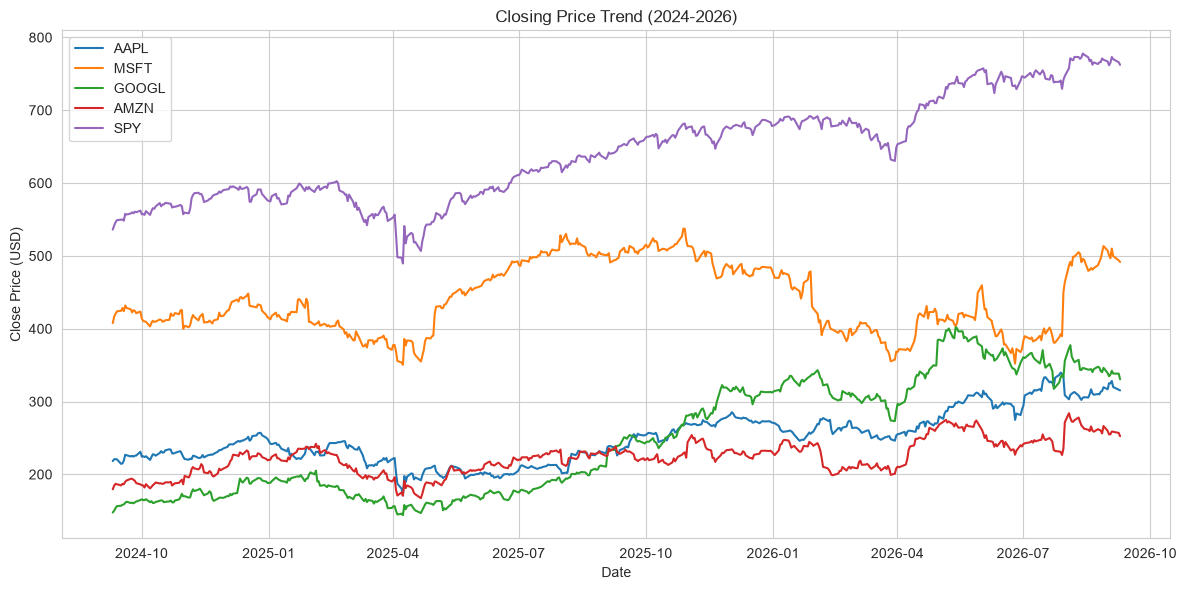

In [8]:
plt.figure(figsize=(12,6))

for ticker in df["Ticker"].unique():
    ticker_data = df[df["Ticker"] == ticker]
    plt.plot(ticker_data["Date"], ticker_data["Close"], label=ticker)

plt.title("Closing Price Trend (2024-2026)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

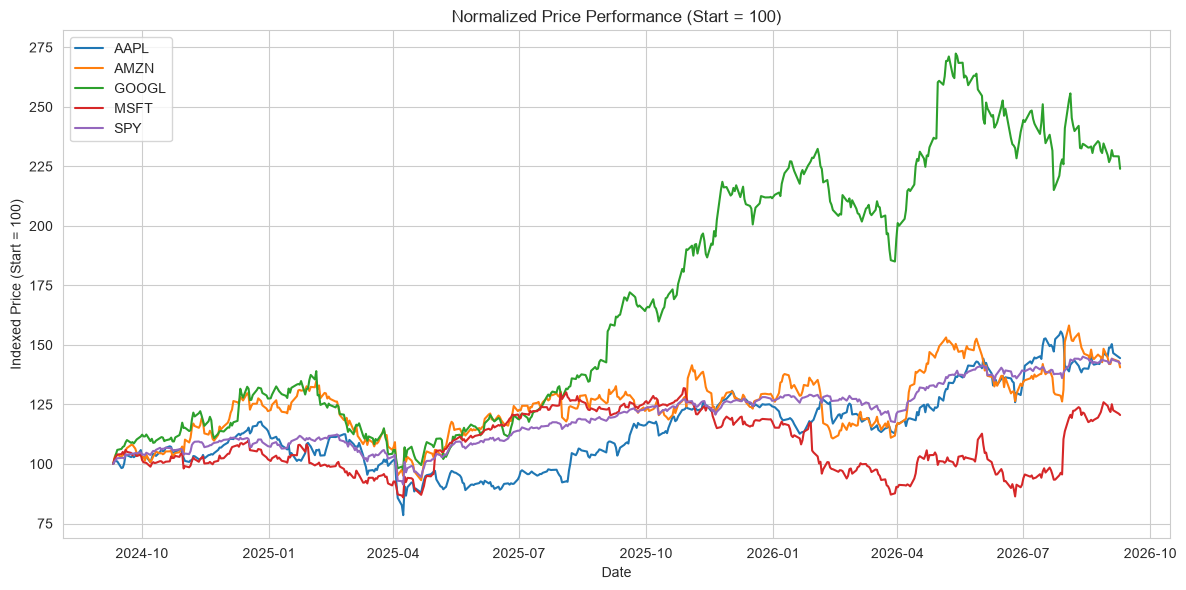

In [10]:
df_pivot = df.pivot(index="Date", columns="Ticker", values="Close")
df_normalized = df_pivot / df_pivot.iloc[0] * 100

plt.figure(figsize=(12,6))
for ticker in df_normalized.columns:
    plt.plot(df_normalized.index, df_normalized[ticker], label=ticker)

plt.title("Normalized Price Performance (Start = 100)")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.tight_layout()
plt.show()

Daily volatility by ticker (%):
Ticker
AMZN     2.141464
GOOGL    2.000594
MSFT     1.820614
AAPL     1.820045
SPY      1.041194
dtype: float64


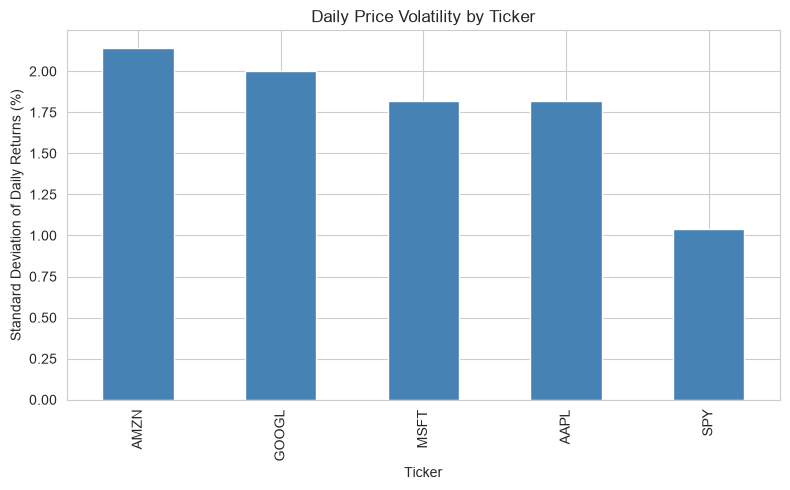

In [14]:
df_returns = df_pivot.pct_change().dropna()
volatility = df_returns.std() * 100

print("Daily volatility by ticker (%):")
print(volatility.sort_values(ascending=False))

plt.figure(figsize=(8,5))
volatility.sort_values(ascending=False).plot(kind="bar", color="steelblue")
plt.title("Daily Price Volatility by Ticker")
plt.ylabel("Standard Deviation of Daily Returns (%)")
plt.tight_layout()
plt.show()

In [15]:
final_performance = df_normalized.iloc[-1] - 100
print("Total return over the period (%):")
print(final_performance.sort_values(ascending=False).round(1))

Total return over the period (%):
Ticker
GOOGL    124.0
AAPL      44.5
SPY       42.2
AMZN      40.6
MSFT      20.6
Name: 2026-09-09 04:00:00, dtype: float64


## Key Findings

- Over the 2-year period, **GOOGL** was the standout performer with a **+124.0%** total return - more than double the next-best ticker.
- **AAPL** (+44.5%), **SPY** (+42.2%) and **AMZN** (+40.6%) posted similar, moderate returns.
- **MSFT** lagged notably behind, up only **+20.6%** over the same period.
- **AMZN** (2.14%) and **GOOGL** (2.00%) were the most volatile on a daily basis, while **SPY** was by far the most stable (1.04%) - consistent with it being a diversified index rather than a single stock.
- Data quality was high: only one row out of 2,506 (0.04%) had missing values and was removed; no duplicates were found.

**Next Step:** build a forecasting model to predict future price trends, using these patterns as a baseline.